# Predicting Loan Payback
Playground Series - Season 5, Episode 11

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
# Libraries for data preprocessing and visualization
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

import optuna
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
# Prepare libraries for Deep Learning models with Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision.models as models

In [3]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


## Data Loading

In [4]:
df_train = pd.read_csv('C:\\Users\\Blix\\Documents\\GitHub\\ml-development\\kaggle\\Playground_Predicting Loan Payback\\train.csv')
df_test = pd.read_csv('C:\\Users\\Blix\\Documents\\GitHub\\ml-development\\kaggle\\Playground_Predicting Loan Payback\\test.csv')
df_sample_submission = pd.read_csv('C:\\Users\\Blix\\Documents\\GitHub\\ml-development\\kaggle\\Playground_Predicting Loan Payback\\sample_submission.csv')

In [5]:
df_train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [7]:
df_train.duplicated().sum()

np.int64(0)

In [8]:
df_train.isna().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [9]:
# Check number of unique values in each column
df_train.nunique()

id                      593994
annual_income           119728
debt_to_income_ratio       526
credit_score               399
loan_amount             111570
interest_rate             1454
gender                       3
marital_status               4
education_level              5
employment_status            5
loan_purpose                 8
grade_subgrade              30
loan_paid_back               2
dtype: int64

## Data Cleaning

In [ ]:
# Label encoding for categorical features
df_train.drop(columns=['id'], inplace=True)
categorical_cols = df_train.select_dtypes(include=['object']).columns
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
# Remove accident_risk in numerical_cols
numerical_cols = numerical_cols.drop('accident_risk')

In [ ]:
# Create duplicate of dataframe to preserve original data
df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

## Exploratory Data Analysis

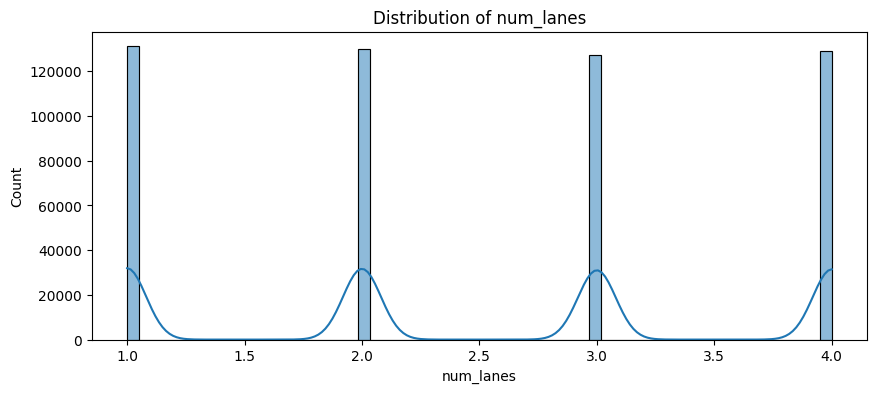

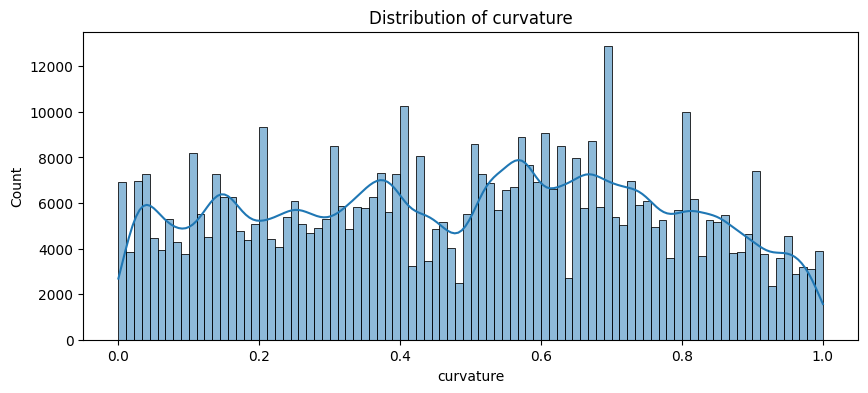

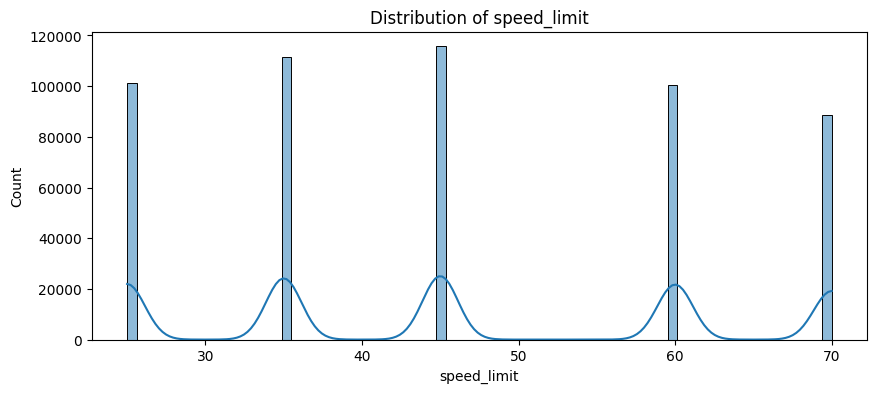

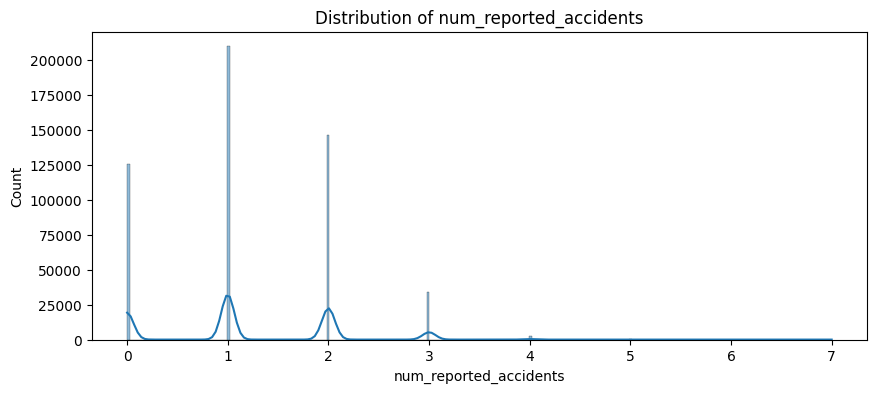

In [ ]:
# Visualize the distribution of numerical features
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df_train_processed[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

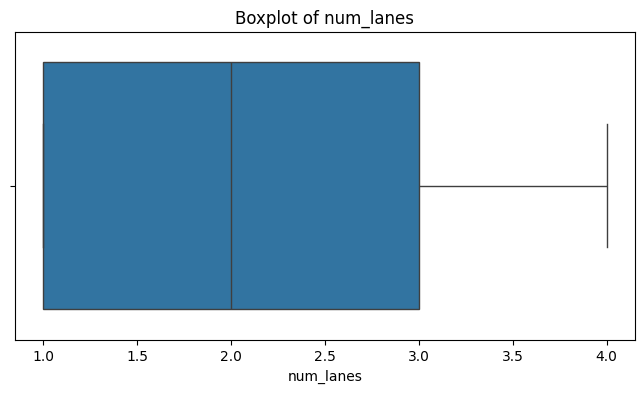

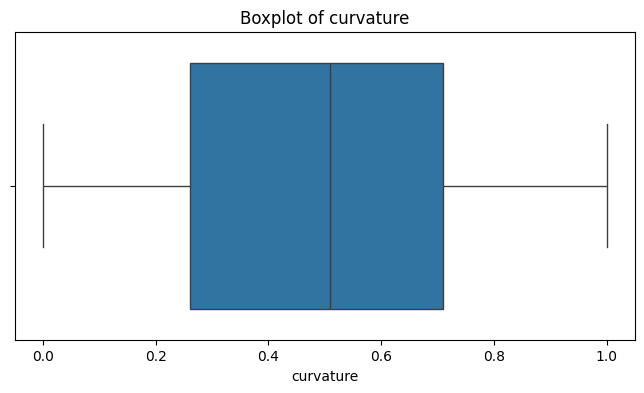

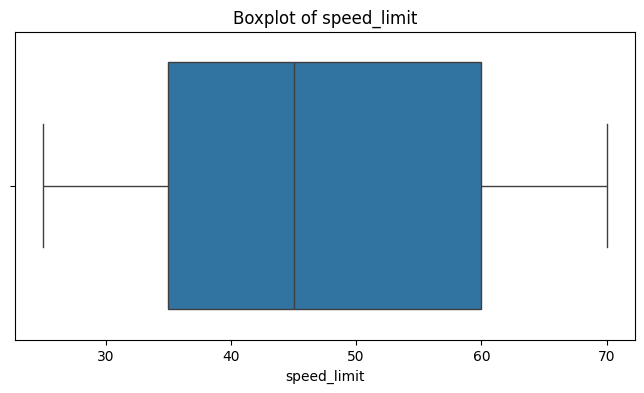

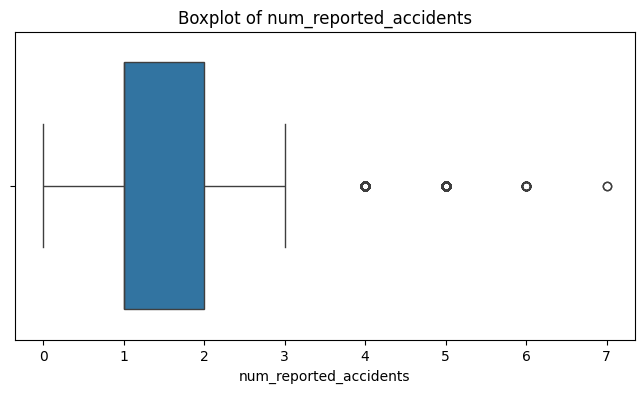

In [ ]:
# Use boxplot to identify outliers in numerical features
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train_processed[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

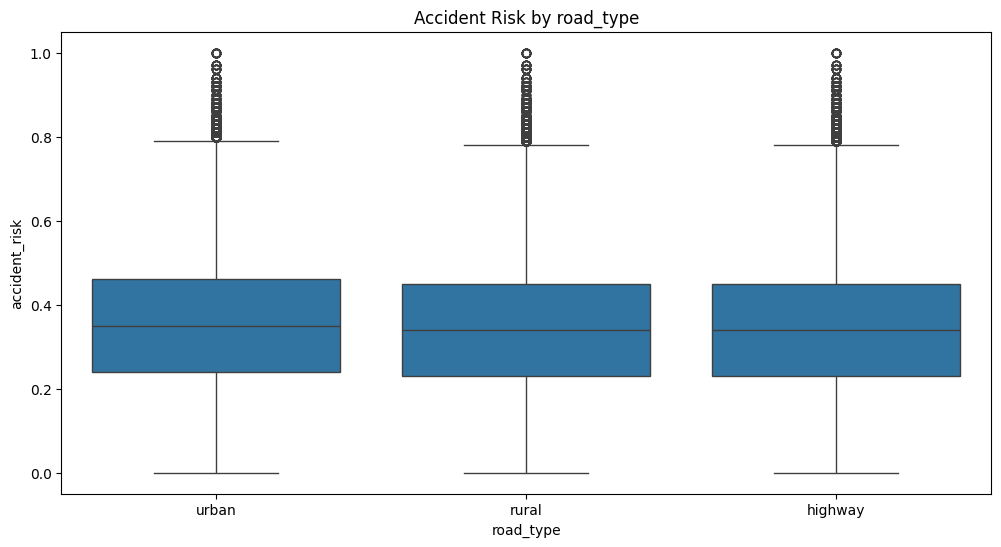

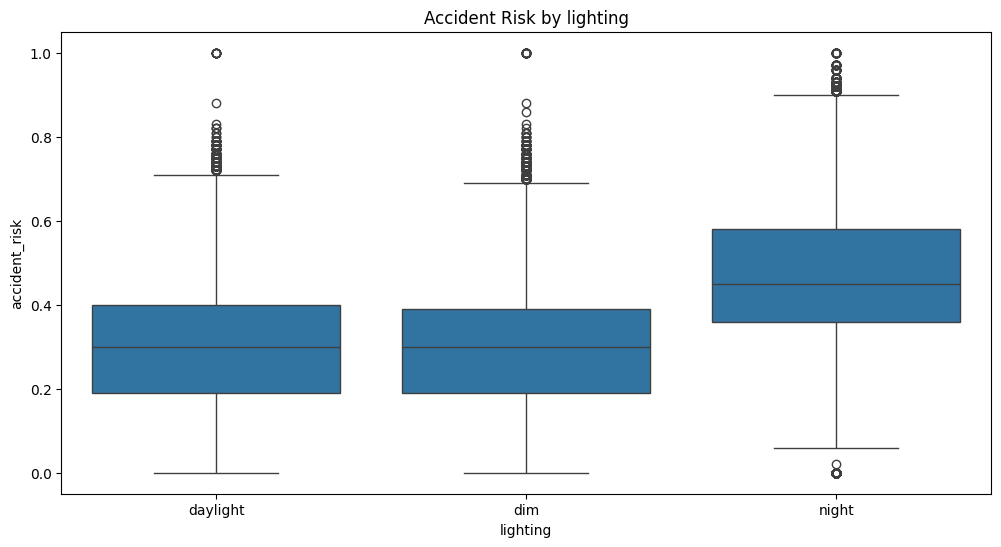

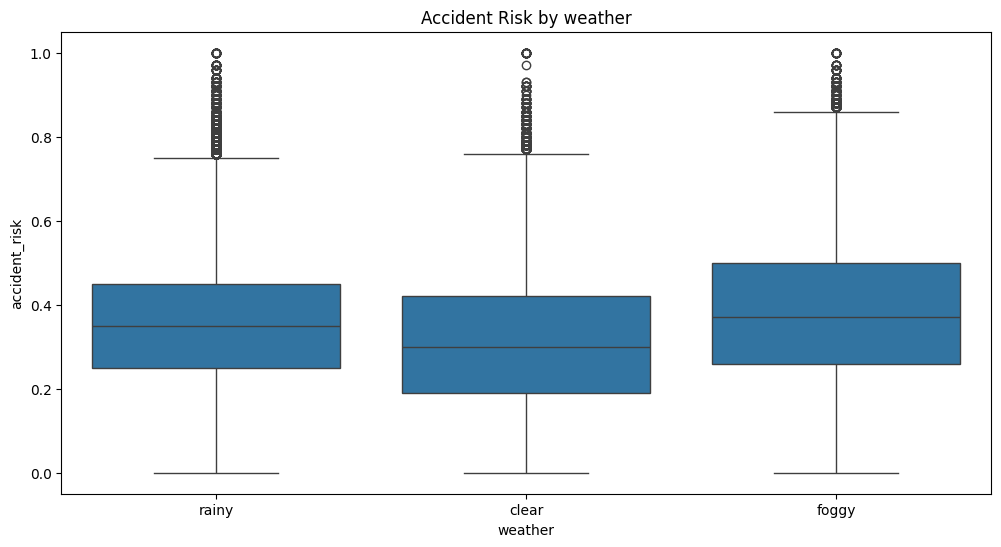

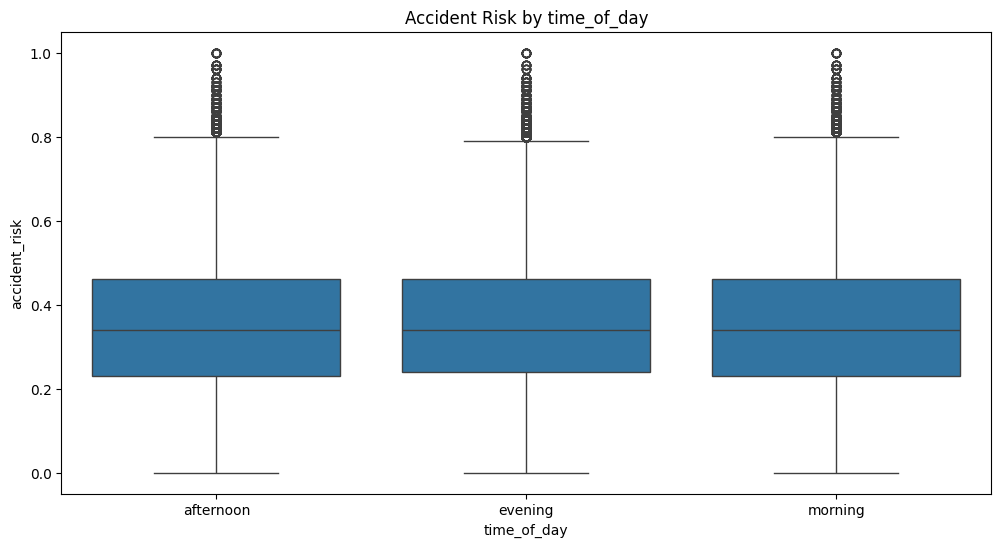

In [ ]:
# Check distribution of accident risk based on categorical features
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df_train_processed[col], y=df_train_processed['accident_risk'])
    plt.title(f'Accident Risk by {col}')
    plt.show()

## Feature Engineering

In [ ]:
# Convert categorical columns using One-Hot Encoding
df_train_processed = pd.get_dummies(df_train_processed, columns=categorical_cols)
df_test_processed = pd.get_dummies(df_test_processed, columns=categorical_cols)

# Align the train and test sets
df_train_processed, df_test_processed = df_train_processed.align(df_test_processed, join='left', axis=1, fill_value=0)

In [ ]:
# Convert bool columns to integers
bool_cols = df_train_processed.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_train_processed[col] = df_train_processed[col].astype(int)
    df_test_processed[col] = df_test_processed[col].astype(int)

In [ ]:
df_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   num_lanes               517754 non-null  int64  
 1   curvature               517754 non-null  float64
 2   speed_limit             517754 non-null  int64  
 3   road_signs_present      517754 non-null  int64  
 4   public_road             517754 non-null  int64  
 5   holiday                 517754 non-null  int64  
 6   school_season           517754 non-null  int64  
 7   num_reported_accidents  517754 non-null  int64  
 8   accident_risk           517754 non-null  float64
 9   road_type_highway       517754 non-null  int64  
 10  road_type_rural         517754 non-null  int64  
 11  road_type_urban         517754 non-null  int64  
 12  lighting_daylight       517754 non-null  int64  
 13  lighting_dim            517754 non-null  int64  
 14  lighting_night      

## Train-Test-Split

In [ ]:
# Perform 80-20 train-test split
X = df_train_processed.drop(columns=['accident_risk'])
y = df_train_processed['accident_risk']

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Perform Standard Scaling on numerical features
scaler = StandardScaler()

In [ ]:
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])

In [ ]:
df_test_processed[numerical_cols] = scaler.transform(df_test_processed[numerical_cols])

## Model Training

In [ ]:
# Train using RandomForestRegressor and XGBRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Model Evaluation

In [ ]:
# Check test set predictions
rf_test_preds = rf_model.predict(X_val)
xgb_test_preds = xgb_model.predict(X_val)

In [ ]:
# Check RMSE on validation set
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_test_preds))
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_test_preds))
print(f'Random Forest RMSE: {rf_rmse}')
print(f'XGBoost RMSE: {xgb_rmse}')

Random Forest RMSE: 0.05941096024782406
XGBoost RMSE: 0.05626601768293998


## Hyperparameter Tuning

In [ ]:
import xgboost as xgb

In [ ]:
# Import optuna for hyperparameter tuning using XGBRegressor and early stopping
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 2.0),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 5),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9, step=0.05),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 0.9, step=0.05),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.6, 0.9, step=0.05),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 5.0, log=True),
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "random_state": 42,
        "tree_method": "hist",
    }

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    early_stopping_rounds = trial.suggest_int("early_stopping_rounds", 50, 200, step=25)
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-mae")

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        evals=[(dval, 'validation')],
        num_boost_round=params['n_estimators'],
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=False,
        callbacks=[pruning_callback]
    )

    preds = model.predict(dval)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse


In [ ]:
# Remove user warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# Run optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5000)
best_params = study.best_params
print("Best parameters:", best_params)


[I 2025-10-31 13:01:06,094] A new study created in memory with name: no-name-64920671-651c-4940-b8ad-765452510daf
[I 2025-10-31 13:01:09,074] Trial 0 finished with value: 0.05713301313337428 and parameters: {'max_depth': 6, 'min_child_weight': 7, 'gamma': 1.1213240100457602, 'n_estimators': 800, 'learning_rate': 0.01172790490705853, 'max_delta_step': 1, 'subsample': 0.75, 'colsample_bytree': 0.6, 'colsample_bylevel': 0.9, 'colsample_bynode': 0.7, 'reg_alpha': 0.003254770686409909, 'reg_lambda': 0.0460197366195993, 'early_stopping_rounds': 125}. Best is trial 0 with value: 0.05713301313337428.
[I 2025-10-31 13:01:10,362] Trial 1 finished with value: 0.05753201044608447 and parameters: {'max_depth': 4, 'min_child_weight': 8, 'gamma': 1.1467689153347989, 'n_estimators': 600, 'learning_rate': 0.049247163996304036, 'max_delta_step': 5, 'subsample': 0.75, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.8, 'colsample_bynode': 0.65, 'reg_alpha': 0.13732648639531878, 'reg_lambda': 1.72662454336

KeyboardInterrupt: 

## Tuned Model

In [ ]:
# Use best parameters to train final XGBRegressor model with early stopping
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
early_stopping_rounds = best_params.get("early_stopping_rounds", 100)

model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    evals=[(dval, 'validation')],
    num_boost_round=best_params['n_estimators'],
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=True
)

[0]	validation-rmse:0.14747
[1]	validation-rmse:0.12408
[2]	validation-rmse:0.10723
[3]	validation-rmse:0.09328
[4]	validation-rmse:0.08255
[5]	validation-rmse:0.07637
[6]	validation-rmse:0.07161
[7]	validation-rmse:0.06680
[8]	validation-rmse:0.06341
[9]	validation-rmse:0.06112
[10]	validation-rmse:0.06001
[11]	validation-rmse:0.05915
[12]	validation-rmse:0.05828
[13]	validation-rmse:0.05760
[14]	validation-rmse:0.05715
[15]	validation-rmse:0.05694
[16]	validation-rmse:0.05677
[17]	validation-rmse:0.05673
[18]	validation-rmse:0.05658
[19]	validation-rmse:0.05647
[20]	validation-rmse:0.05640
[21]	validation-rmse:0.05634
[22]	validation-rmse:0.05632
[23]	validation-rmse:0.05629
[24]	validation-rmse:0.05627
[25]	validation-rmse:0.05626
[26]	validation-rmse:0.05625
[27]	validation-rmse:0.05625
[28]	validation-rmse:0.05624
[29]	validation-rmse:0.05623
[30]	validation-rmse:0.05623
[31]	validation-rmse:0.05623
[32]	validation-rmse:0.05622
[33]	validation-rmse:0.05622
[34]	validation-rmse:0.0

In [ ]:
# predict on test set of best model
xgb_test_preds = model.predict(dval)
# Check RMSE on validation set
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_test_preds))
print(f'XGBoost RMSE: {xgb_rmse}')

XGBoost RMSE: 0.056202048792543056


In [ ]:
# Plot feature importance
importance = model.get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()

## Submission File Creation

In [ ]:
# Create submission file for RandomForestRegressor
rf_submission_preds = rf_model.predict(df_test_processed.drop(columns=['id']))
submission_rf = pd.DataFrame({
    'id': df_test['id'],
    'accident_risk': rf_submission_preds
})

In [ ]:
# export to csv
submission_rf.to_csv('rf_submission.csv', index=False)

In [ ]:
# Create submission file for XGBRegressor
xgb_submission_preds = xgb_model.predict(df_test_processed.drop(columns=['id']))
submission_xgb = pd.DataFrame({
    'id': df_test['id'],
    'accident_risk': xgb_submission_preds
})

In [ ]:
# Export to csv
submission_xgb.to_csv('xgb_submission.csv', index=False)

In [ ]:
# Create submission file for Tuned XGBRegressor
tuned_xgb_submission_preds = model.predict(xgb.DMatrix(df_test_processed.drop(columns=['id'])))
submission_tuned_xgb = pd.DataFrame({
    'id': df_test['id'],
    'accident_risk': tuned_xgb_submission_preds
})


In [ ]:
# Export to csv
submission_tuned_xgb.to_csv('tuned_xgb_submission.csv', index=False)